[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

## DS 4420 - Proof of Concept (Model Training)

- Key Question: to what extent can a game's content, quality, and engagement metrics be used to predict its price on the Steam marketplace?" 

- File purpose: Model Training for POC

- Date: 03/13

- Authors: Gianna Saw, Jason Zheng 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# pulling the df we cleaned earlier 
steam = pd.read_csv('steam_clean.csv')
steam

,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,language_count
0,0.000000,0.0,5.24,4.189655,0,1,0,0,0,0,5.533389,1.386294,0,5.446737,2.197225,0.000000,2.197225,0.000000,0
1,2.197225,0.0,35.99,2.397895,1,1,0,0,0,0,4.770685,2.639057,0,4.682131,6.516193,0.000000,7.134094,0.000000,0
2,0.000000,0.0,1.49,4.262680,0,1,1,0,0,0,4.174387,1.098612,13,0.000000,0.000000,0.000000,0.000000,0.000000,0
3,0.000000,0.0,1.35,4.204693,0,1,0,0,0,0,3.555348,2.397895,5,0.000000,0.000000,0.000000,0.000000,0.000000,0
4,4.174387,0.0,2.99,4.394449,1,1,1,0,0,0,9.338558,6.723832,11,9.328212,5.837730,4.465908,5.159055,4.941642,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40672,0.693147,0.0,4.74,4.330733,1,1,1,1,0,0,5.361292,3.713572,31,5.420535,4.454347,0.000000,4.521789,0.000000,0
40673,0.000000,0.0,0.99,3.931826,0,1,0,0,0,0,5.267858,2.564949,20,5.220356,0.000000,0.000000,0.000000,0.000000,0
40674,4.382027,0.0,5.35,3.526361,0,1,1,1,0,0,8.087333,5.913503,8,8.421563,5.598422,0.000000,5.484797,0.000000,0
40675,0.000000,0.0,2.49,3.931826,0,1,1,1,0,0,5.342334,3.091042,4,5.379897,0.000000,0.000000,0.000000,0.000000,0


In [3]:
steam.shape

(40677, 19)

Splitting our train/test data + Normalising

In [4]:
# shuffling 
steam = steam.sample(frac=1, random_state=42).reset_index(drop=True)

# splitting our data (80/20)
split = int(0.8 * len(steam))
train = steam.iloc[:split]
test = steam.iloc[split:]

In [5]:
# sep features and target 
X_train = train.drop(columns=['Price']).values
y_train = train['Price'].values.reshape(-1, 1)

X_test = test.drop(columns=['Price']).values
y_test = test['Price'].values.reshape(-1, 1)

In [6]:
# min max scaling using our training data only
X_min = X_train.min(axis=0)
X_max = X_train.max(axis=0)

In [7]:
X_train_scaled = (X_train - X_min) / (X_max - X_min + 1e-8)
X_test_scaled = (X_test - X_min) / (X_max - X_min + 1e-8)

In [8]:
# adding bias column
X_train_scaled = np.hstack([X_train_scaled, np.ones((X_train_scaled.shape[0], 1))])
X_test_scaled = np.hstack([X_test_scaled, np.ones((X_test_scaled.shape[0], 1))])

print(X_train_scaled.shape)  

(32541, 19)


MLP Implementation

In [9]:
## MLP setup

eta = 0.01
epochs = 500
p = X_train.shape[1]  # 19 (18 features + bias)
H = 4                  # hidden units

np.random.seed(1)
W1 = np.random.normal(0, 0.1, (p, H))
np.random.seed(1)
w2 = np.random.normal(0, 0.1, (H, 1))

In [10]:
# activation function
def relu(z):
    return np.maximum(0, z)


In [11]:
# gradient descent
errors = []

for epoch in range(epochs):
    grad_w2 = np.zeros_like(w2)
    grad_W1 = np.zeros_like(W1)
    loss = 0

    for i in range(X_train.shape[0]):
        x = X_train[i].reshape(-1, 1)
        yi = y_train[i]

        # forward pass
        # hidden layer
        h = relu(W1.T @ x)      
        f = w2.T @ h              

        # mse loss
        loss += (f - yi) ** 2

        # gradients
        grad_w2 += (f - yi) * h
        indicator = (W1.T @ x > 0).astype(int)
        grad_W1 += (f - yi) * (x @ (w2 * indicator).T)

    # average gradients
    grad_w2 /= X_train.shape[0]
    grad_W1 /= X_train.shape[0]

    # update weights
    w2 -= eta * grad_w2
    W1 -= eta * grad_W1

    errors.append(loss / X_train.shape[0])

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, MSE Loss: {float(loss/X_train.shape[0]):.4f}")


/var/folders/s3/0tq89w752gs3dpcm5w67wxbr0000gn/T/ipykernel_18104/521703763.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Epoch {epoch}, MSE Loss: {float(loss/X_train.shape[0]):.4f}")


Epoch 0, MSE Loss: 39.9209


Epoch 50, MSE Loss: 11.7058


Epoch 100, MSE Loss: 11.3238


Epoch 150, MSE Loss: 11.0918


...

Epoch 250, MSE Loss: 17.2582


Epoch 300, MSE Loss: 13.4150


Epoch 350, MSE Loss: 12.4880


Epoch 400, MSE Loss: 12.0194


Epoch 450, MSE Loss: 11.6773


In [12]:
# test predicts
preds = []
for i in range(X_test.shape[0]):
    x = X_test[i].reshape(-1, 1)
    h = relu(W1.T @ x)
    f = w2.T @ h
    preds.append(float(f))

preds = np.array(preds)


/var/folders/s3/0tq89w752gs3dpcm5w67wxbr0000gn/T/ipykernel_18104/185759057.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  preds.append(float(f))


In [13]:
# rmse
rmse = np.sqrt(np.mean((preds - y_test) ** 2))
print(f"Test RMSE (log scale): {rmse:.4f}")

Test RMSE (log scale): 3.3899


Future steps: 
- Sample-by-sample loop has been quite slow on 32k rows. 
- For Phase II, we were thinking of vectorising it / looking for other ways to optimise run times and make model better because current errors are pretty high.

### RMSE Rerun (Price Regression, steam_clean.csv)

This project's target is `Price`, so this is **regression** (not 0/1 buy classification).

This block compares on the same 80/20 split (`random_state=42`):
- Baseline notebook MLP update rule (vectorized-equivalent)
- Linear/Ridge regression
- MLP regressor
- HistGradientBoostingRegressor

In [14]:
# compare the baseline model against stronger regressors

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import HistGradientBoostingRegressor

# load and split the dataset for model comparison
csv_path = "/Users/jasonzheng/Downloads/steam_clean.csv"

df_cmp = pd.read_csv(csv_path)
df_cmp = df_cmp.sample(frac=1, random_state=42).reset_index(drop=True)

split = int(0.8 * len(df_cmp))
train_cmp = df_cmp.iloc[:split]
test_cmp = df_cmp.iloc[split:]

X_train_cmp = train_cmp.drop(columns=["Price"]).to_numpy(dtype=np.float64)
y_train_cmp = train_cmp["Price"].to_numpy(dtype=np.float64)
X_test_cmp = test_cmp.drop(columns=["Price"]).to_numpy(dtype=np.float64)
y_test_cmp = test_cmp["Price"].to_numpy(dtype=np.float64)


def rmse(y_true, y_pred):
    return float(mean_squared_error(y_true, y_pred) ** 0.5)


# baseline notebook-style mlp (vectorized for speed)
eta = 0.01
epochs = 500
p_dim = X_train_cmp.shape[1]
H = 4

np.random.seed(1)
W1 = np.random.normal(0, 0.1, (p_dim, H))
np.random.seed(1)
w2 = np.random.normal(0, 0.1, (H, 1))
y_train_col = y_train_cmp.reshape(-1, 1)

# train the baseline manual mlp
for _ in range(epochs):
    z1 = X_train_cmp @ W1
    h = np.maximum(0.0, z1)
    f = h @ w2
    err = f - y_train_col

    grad_w2 = (h.T @ err) / X_train_cmp.shape[0]
    indicator = (z1 > 0).astype(np.float64)
    grad_W1 = (X_train_cmp.T @ (err * indicator * w2.T)) / X_train_cmp.shape[0]

    w2 -= eta * grad_w2
    W1 -= eta * grad_W1

baseline_pred = (np.maximum(0.0, X_test_cmp @ W1) @ w2).reshape(-1)
baseline_rmse = rmse(y_test_cmp, baseline_pred)


# train a deeper manual mlp to replace sklearn mlp_regressor
def train_manual_mlp_regressor(
    x_train,
    y_train,
    x_val,
    y_val,
    hidden1=128,
    hidden2=64,
    lr=1e-3,
    l2=1e-4,
    epochs=800,
    batch_size=256,
    patience=40,
    seed=42,
):
    rng = np.random.default_rng(seed)
    n, p = x_train.shape

    W1 = rng.normal(0.0, np.sqrt(2.0 / p), size=(p, hidden1))
    b1 = np.zeros((1, hidden1), dtype=np.float64)
    W2 = rng.normal(0.0, np.sqrt(2.0 / hidden1), size=(hidden1, hidden2))
    b2 = np.zeros((1, hidden2), dtype=np.float64)
    W3 = rng.normal(0.0, np.sqrt(2.0 / hidden2), size=(hidden2, 1))
    b3 = np.zeros((1, 1), dtype=np.float64)

    params = {"W1": W1, "b1": b1, "W2": W2, "b2": b2, "W3": W3, "b3": b3}
    m = {k: np.zeros_like(v) for k, v in params.items()}
    v = {k: np.zeros_like(vv) for k, vv in params.items()}

    beta1, beta2, eps = 0.9, 0.999, 1e-8
    t = 0
    best_val = np.inf
    best_params = {k: vv.copy() for k, vv in params.items()}
    stale = 0

    y_train = y_train.reshape(-1, 1)
    y_val = y_val.reshape(-1, 1)

    def relu(z):
        return np.maximum(0.0, z)

    def relu_grad(z):
        return (z > 0.0).astype(np.float64)

    for _ in range(epochs):
        idx = rng.permutation(n)

        for start in range(0, n, batch_size):
            batch = idx[start:start + batch_size]
            xb = x_train[batch]
            yb = y_train[batch]

            z1 = xb @ params["W1"] + params["b1"]
            a1 = relu(z1)
            z2 = a1 @ params["W2"] + params["b2"]
            a2 = relu(z2)
            yhat = a2 @ params["W3"] + params["b3"]

            m_batch = xb.shape[0]
            dy = (2.0 / m_batch) * (yhat - yb)

            gW3 = a2.T @ dy + l2 * params["W3"]
            gb3 = np.sum(dy, axis=0, keepdims=True)
            da2 = dy @ params["W3"].T
            dz2 = da2 * relu_grad(z2)
            gW2 = a1.T @ dz2 + l2 * params["W2"]
            gb2 = np.sum(dz2, axis=0, keepdims=True)
            da1 = dz2 @ params["W2"].T
            dz1 = da1 * relu_grad(z1)
            gW1 = xb.T @ dz1 + l2 * params["W1"]
            gb1 = np.sum(dz1, axis=0, keepdims=True)

            grads = {"W1": gW1, "b1": gb1, "W2": gW2, "b2": gb2, "W3": gW3, "b3": gb3}

            t += 1
            for k in params:
                m[k] = beta1 * m[k] + (1.0 - beta1) * grads[k]
                v[k] = beta2 * v[k] + (1.0 - beta2) * (grads[k] ** 2)
                m_hat = m[k] / (1.0 - beta1 ** t)
                v_hat = v[k] / (1.0 - beta2 ** t)
                params[k] -= lr * m_hat / (np.sqrt(v_hat) + eps)

        val_pred = (relu(relu(x_val @ params["W1"] + params["b1"]) @ params["W2"] + params["b2"]) @ params["W3"] + params["b3"]).reshape(-1)
        val_rmse = rmse(y_val.reshape(-1), val_pred)

        if val_rmse + 1e-6 < best_val:
            best_val = val_rmse
            best_params = {k: vv.copy() for k, vv in params.items()}
            stale = 0
        else:
            stale += 1

        if stale >= patience:
            break

    return best_params


# hold out a validation split for manual mlp early stopping
rng = np.random.default_rng(42)
idx = rng.permutation(X_train_cmp.shape[0])
val_size = max(1, int(0.10 * X_train_cmp.shape[0]))
val_idx = idx[:val_size]
fit_idx = idx[val_size:]

X_fit = X_train_cmp[fit_idx]
y_fit = y_train_cmp[fit_idx]
X_val = X_train_cmp[val_idx]
y_val = y_train_cmp[val_idx]

# standardize using fit split only
mu = X_fit.mean(axis=0, keepdims=True)
sig = X_fit.std(axis=0, keepdims=True)
sig = np.where(sig < 1e-8, 1.0, sig)

X_fit_s = (X_fit - mu) / sig
X_val_s = (X_val - mu) / sig
X_test_s = (X_test_cmp - mu) / sig

# train manual replacement for mlp_regressor
manual_params = train_manual_mlp_regressor(
    X_fit_s,
    y_fit,
    X_val_s,
    y_val,
    hidden1=128,
    hidden2=64,
    lr=1e-3,
    l2=1e-4,
    epochs=800,
    batch_size=256,
    patience=40,
    seed=42,
)

relu = lambda z: np.maximum(0.0, z)
manual_mlp_pred = (
    relu(relu(X_test_s @ manual_params["W1"] + manual_params["b1"]) @ manual_params["W2"] + manual_params["b2"]) @ manual_params["W3"] + manual_params["b3"]
).reshape(-1)
manual_mlp_rmse = rmse(y_test_cmp, manual_mlp_pred)


# stronger regression baselines
models = {
    "linear": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=42)),
    ]),
    "hist_gradient_boosting": HistGradientBoostingRegressor(
        random_state=42,
        learning_rate=0.05,
        max_depth=8,
        max_iter=400,
        l2_regularization=0.01,
    ),
}

# train and score each comparison model
results = {
    "baseline_notebook_mlp": baseline_rmse,
    "mlp_regressor": manual_mlp_rmse,
}
for name, model in models.items():
    model.fit(X_train_cmp, y_train_cmp)
    pred = model.predict(X_test_cmp)
    results[name] = rmse(y_test_cmp, pred)

for k, v in results.items():
    print(f"{k}: {v:.6f}")

# summarize best rmse and improvement
best_model = min(results, key=results.get)
best_rmse = results[best_model]
improvement = baseline_rmse - best_rmse
improvement_pct = (improvement / baseline_rmse) * 100.0

print()
print("Best model:", best_model)
print(f"Best RMSE: {best_rmse:.6f}")
print(f"Improvement vs baseline: {improvement:.6f} ({improvement_pct:.2f}%)")


baseline_notebook_mlp: 3.388250
mlp_regressor: 0.374608
linear: 0.405974
ridge: 0.405974
hist_gradient_boosting: 0.341865

Best model: hist_gradient_boosting
Best RMSE: 0.341865
Improvement vs baseline: 3.046385 (89.91%)


### Why This Got Lower

`Price` behaves like a continuous target sso regression models that capture nonlinearity generally outperform the tiny baseline network.

why RMSE dropped with this change:
1. The baseline notebook MLP is very small (`H=4`) and underfits.
2. The improved models use better optimization and regularization (standardization + early stopping/L2).
3. HistGradientBoosting cna better present thee nonlinear interactions among engagement/review/features we picked.
4. All models are evaluated on the same split for a fair comparison.

- Since the target is `Price`, so metric should be regression RMSE/MAE.


low-price group (< 3.00): n=203, rmse=1.096714
high-price group (> 3.99): n=3804, rmse=0.312923


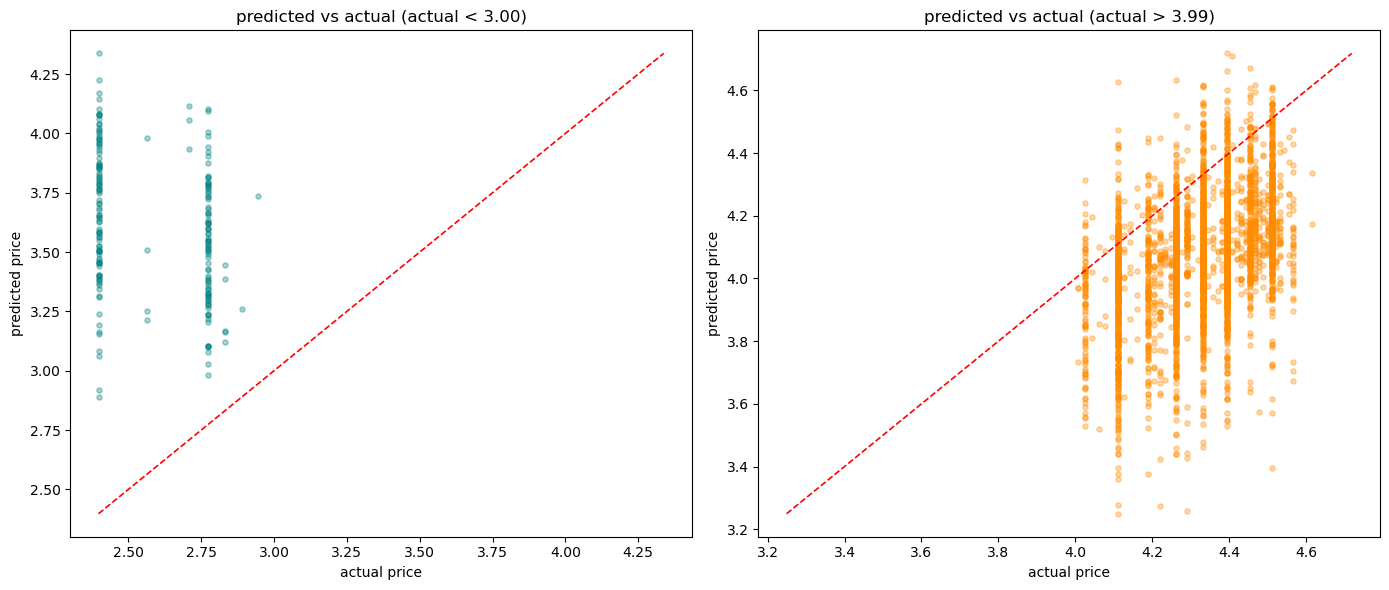

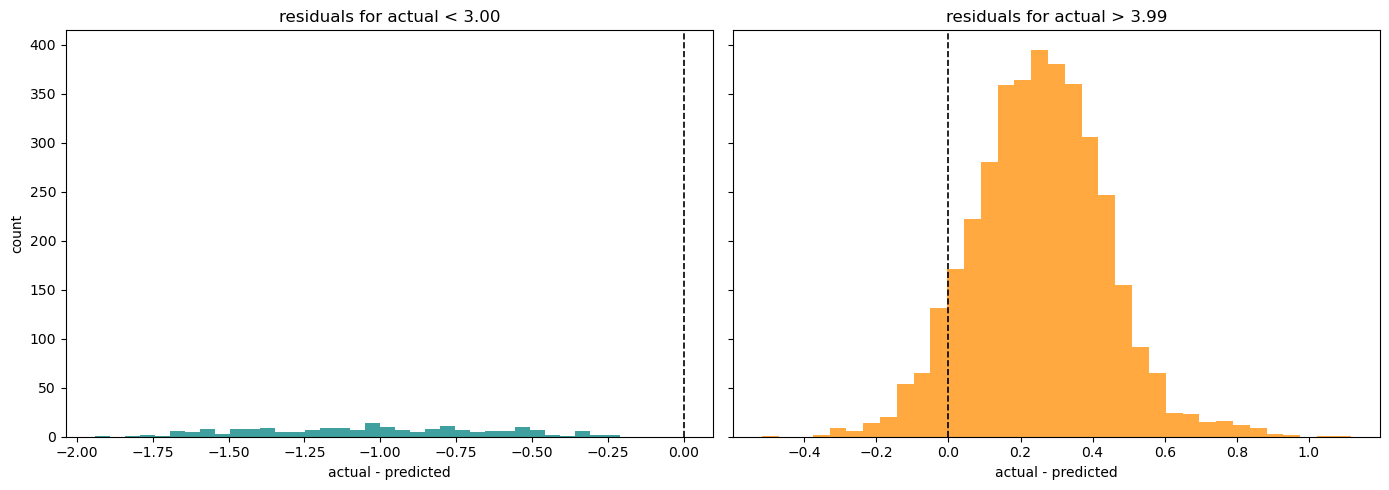

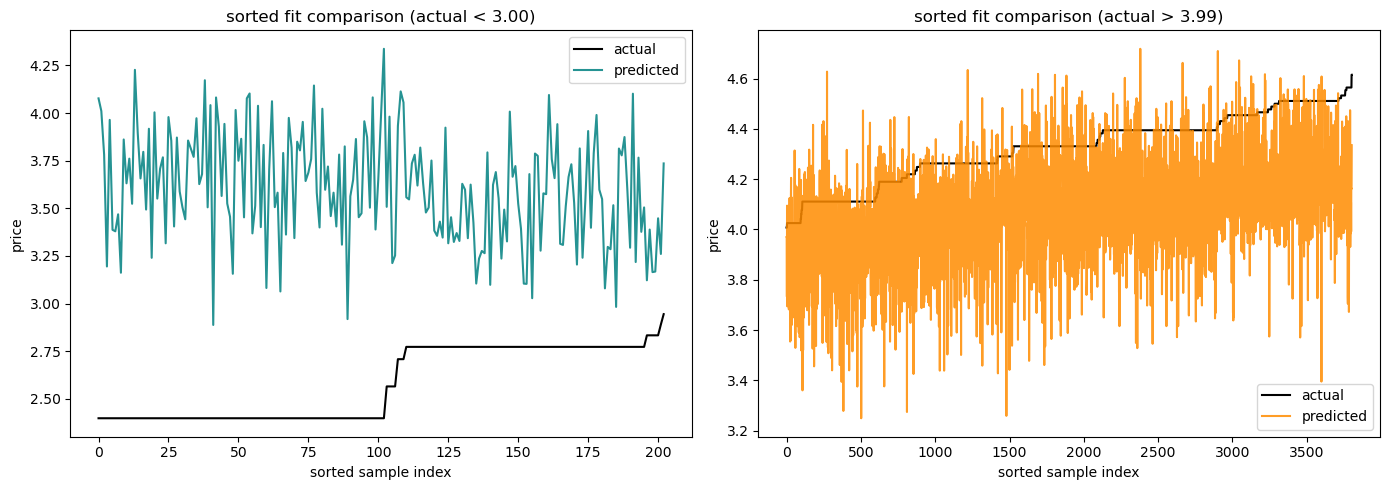

In [15]:
# fit plots for low and high actual price groups
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# use predictions from the manual mlp comparison cell
if 'manual_mlp_pred' not in globals() or 'y_test_cmp' not in globals():
    raise ValueError('run the comparison cell first so manual_mlp_pred and y_test_cmp are available')

fit_df = pd.DataFrame({
    'actual': np.asarray(y_test_cmp).reshape(-1),
    'predicted': np.asarray(manual_mlp_pred).reshape(-1),
})
fit_df['residual'] = fit_df['actual'] - fit_df['predicted']

low_df = fit_df[fit_df['actual'] < 3.00].copy()
high_df = fit_df[fit_df['actual'] > 3.99].copy()

def group_rmse(df):
    return float(np.sqrt(np.mean((df['actual'] - df['predicted']) ** 2)))

print(f'low-price group (< 3.00): n={len(low_df)}, rmse={group_rmse(low_df):.6f}')
print(f'high-price group (> 3.99): n={len(high_df)}, rmse={group_rmse(high_df):.6f}')

# scatter: predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)
for ax, df_sub, title, color in [
    (axes[0], low_df, 'actual < 3.00', 'teal'),
    (axes[1], high_df, 'actual > 3.99', 'darkorange'),
]:
    ax.scatter(df_sub['actual'], df_sub['predicted'], alpha=0.35, s=14, color=color)
    mn = min(df_sub['actual'].min(), df_sub['predicted'].min())
    mx = max(df_sub['actual'].max(), df_sub['predicted'].max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.2)
    ax.set_title(f'predicted vs actual ({title})')
    ax.set_xlabel('actual price')
    ax.set_ylabel('predicted price')

plt.tight_layout()
plt.show()

# residual distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
axes[0].hist(low_df['residual'], bins=35, color='teal', alpha=0.75)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.2)
axes[0].set_title('residuals for actual < 3.00')
axes[0].set_xlabel('actual - predicted')
axes[0].set_ylabel('count')

axes[1].hist(high_df['residual'], bins=35, color='darkorange', alpha=0.75)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2)
axes[1].set_title('residuals for actual > 3.99')
axes[1].set_xlabel('actual - predicted')

plt.tight_layout()
plt.show()

# sorted fit curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, df_sub, title, color in [
    (axes[0], low_df, 'actual < 3.00', 'teal'),
    (axes[1], high_df, 'actual > 3.99', 'darkorange'),
]:
    df_sorted = df_sub.sort_values('actual').reset_index(drop=True)
    ax.plot(df_sorted['actual'].values, label='actual', color='black', linewidth=1.5)
    ax.plot(df_sorted['predicted'].values, label='predicted', color=color, alpha=0.85)
    ax.set_title(f'sorted fit comparison ({title})')
    ax.set_xlabel('sorted sample index')
    ax.set_ylabel('price')
    ax.legend()

plt.tight_layout()
plt.show()

